# Presentation figures (260616)

Dataset: `data/embeddings/proof_benchmarked_260505/var-ring-sym_phi-0.95_cpl-0.4/M10_T500_I6`.

Plots: MTS heatmap; MPI heatmaps for `cov_EmpiricalCovariance`, `spearmanr`, `mi_kraskov_NN-4`; unravel off-diagonals to 1D barcode; two-SPI scatter.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import spearmanr, zscore
from sklearn.preprocessing import robust_scale

# ---- tweakable knobs ----
dpi = 500
save_fmt = "svg"  # "png" or "svg"
use_latex = True

DATASET = Path("../../data/r_rho_mi/260617_g-tanhsin_a-0.95_k-2pi_noise-0.05/A-pi_L/M7_T100_I0")
output_dir = Path("figures3")
output_dir.mkdir(parents=True, exist_ok=True)

# Presentation-tuned rcParams. Override individually below if needed.
sns.set_theme(
    style="white",
    rc={
        "text.usetex": use_latex,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 16,
        "axes.titlesize": 22,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
        "legend.title_fontsize": 16,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
        "savefig.transparent": True,
    },
)

# Load meta once (for directedness + labels per SPI)
with (DATASET / "meta.json").open() as f:
    META = json.load(f)
SPI_META = {e["name"]: e for e in META.get("pyspi", {}).get("spis", []) if e.get("name")}
ARCHIVE = DATASET / "spi_mpis.npz"
TAG = f"{DATASET.parent.name}_{DATASET.name}"
TAG

'A-pi_L_M7_T100_I0'

## MTS heatmap

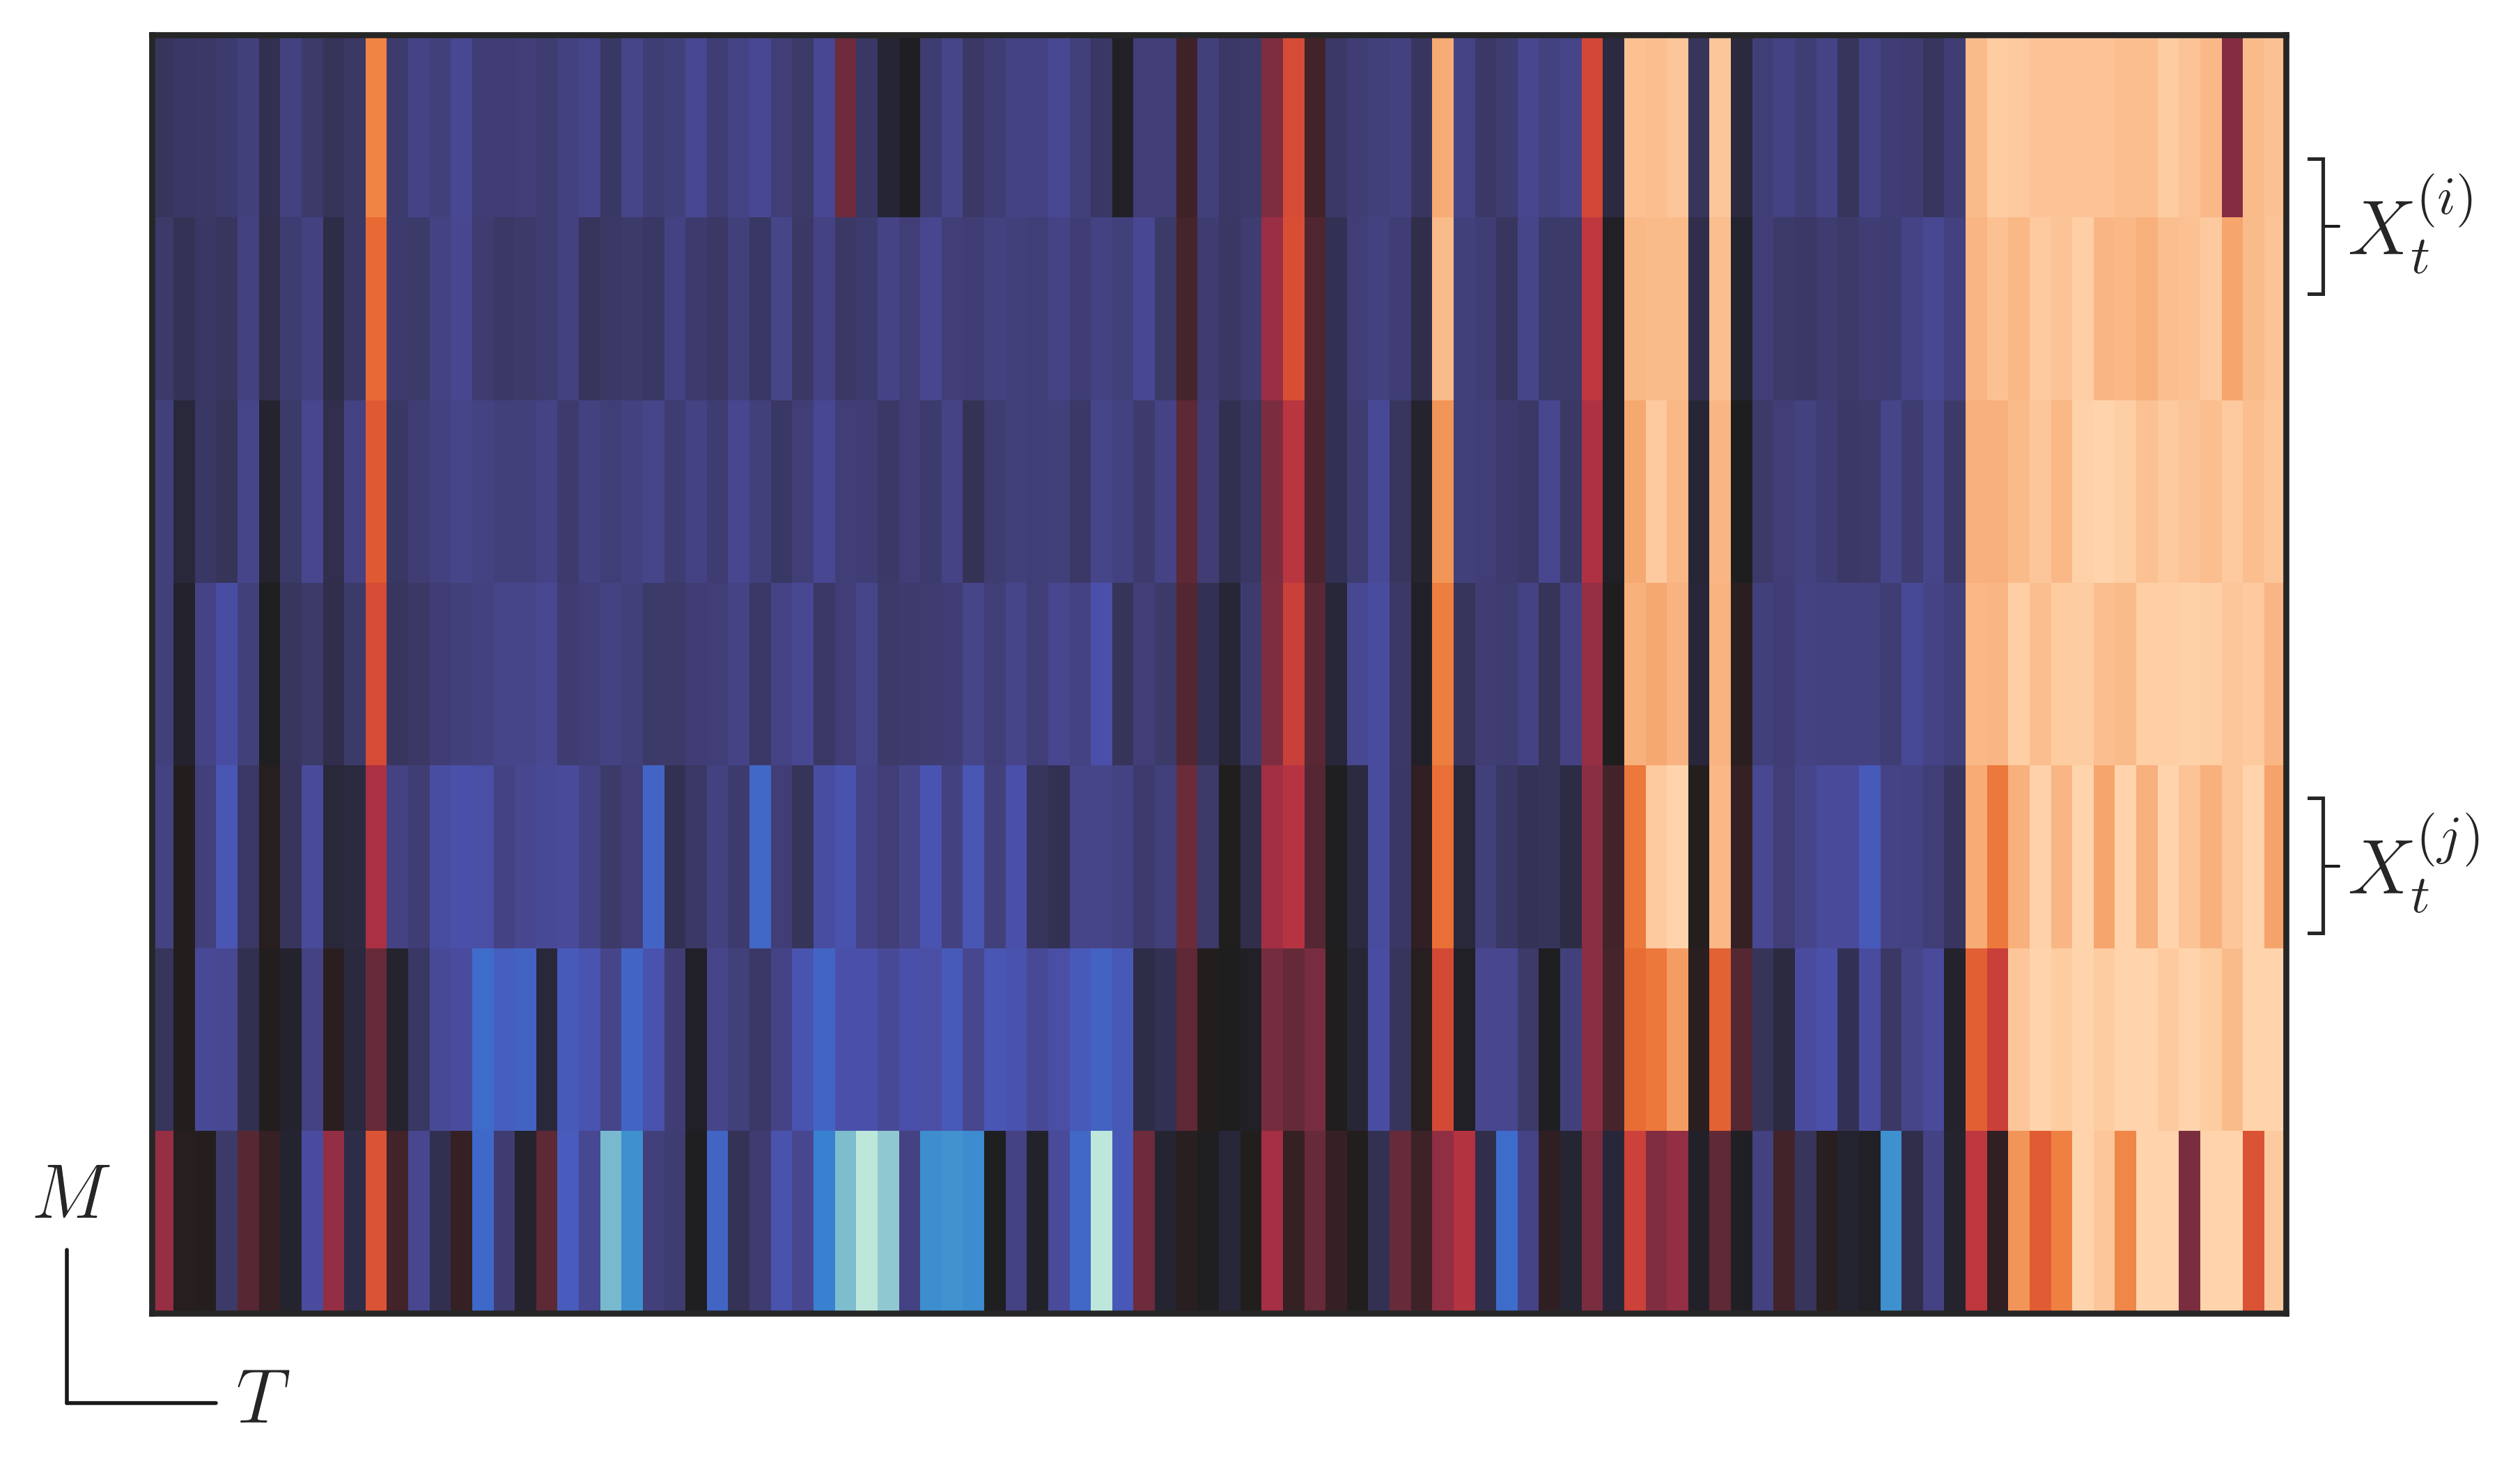

In [2]:
# ---- tweakable ----
mts_cmap = "icefire"
mts_vmin, mts_vmax = -2.0, 2.0
mts_figsize = (7, 4)

data = np.load(DATASET / "timeseries.npy").astype(float)
if data.shape[0] > data.shape[1]:  # ensure (M, T)
    data = data.T
scaled = zscore(data, axis=1, nan_policy="omit")
scaled = np.nan_to_num(scaled, nan=0.0, posinf=0.0, neginf=0.0)

fig, ax = plt.subplots(figsize=mts_figsize, dpi=dpi)
ax.pcolormesh(scaled, shading="flat", vmin=mts_vmin, vmax=mts_vmax,
              cmap=sns.color_palette(mts_cmap, as_cmap=True))
ax.set_xticks([]); ax.set_yticks([])

# axes-fraction coords: (0,0)=bottom-left. Move each freely.
# ax.text(-0.055, 0.00, r"$\uparrow$", transform=ax.transAxes, clip_on=False)
ax.text(-0.055, 0.075, r"$M$", transform=ax.transAxes, clip_on=False)
# ax.text(-0.03, -0.09, r"$\rightarrow$", transform=ax.transAxes, clip_on=False)
ax.text(0.04, -0.085, r"$T$", transform=ax.transAxes, clip_on=False)

ax.text(1.03, 0.828, r"$X_t^{(i)}$", transform=ax.transAxes, clip_on=False)  #8
ax.text(1.03, 0.328, r"$X_t^{(j)}$", transform=ax.transAxes, clip_on=False)  #3

ax.text(1.01, 0.335, r"$\Biggr]$", transform=ax.transAxes, clip_on=False)  #3
# ax.text(1.01, 0.335, r"$\Biggr\}$", transform=ax.transAxes, clip_on=False)  #3
ax.plot([1.018, 1.025], [0.35, 0.35], transform=ax.transAxes, clip_on=False, color="k", lw=0.6)

ax.text(1.01, 0.835, r"$\Biggr]$", transform=ax.transAxes, clip_on=False)  #8
ax.plot([1.018, 1.025], [0.85, 0.85], transform=ax.transAxes, clip_on=False, color="k", lw=0.6)

# lines: ax.plot([x0,x1],[y0,y1]). vertical then horizontal segment near corner.
ax.plot([-0.04, -0.04], [-0.07, 0.05], transform=ax.transAxes, clip_on=False, color="k", lw=0.8)
ax.plot([-0.04, 0.03], [-0.07, -0.07], transform=ax.transAxes, clip_on=False, color="k", lw=0.8)

fig.tight_layout(pad=0.05)
fig.savefig(output_dir / f"mts_heatmap_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight", pad_inches=0)
plt.show()

## Individual channel

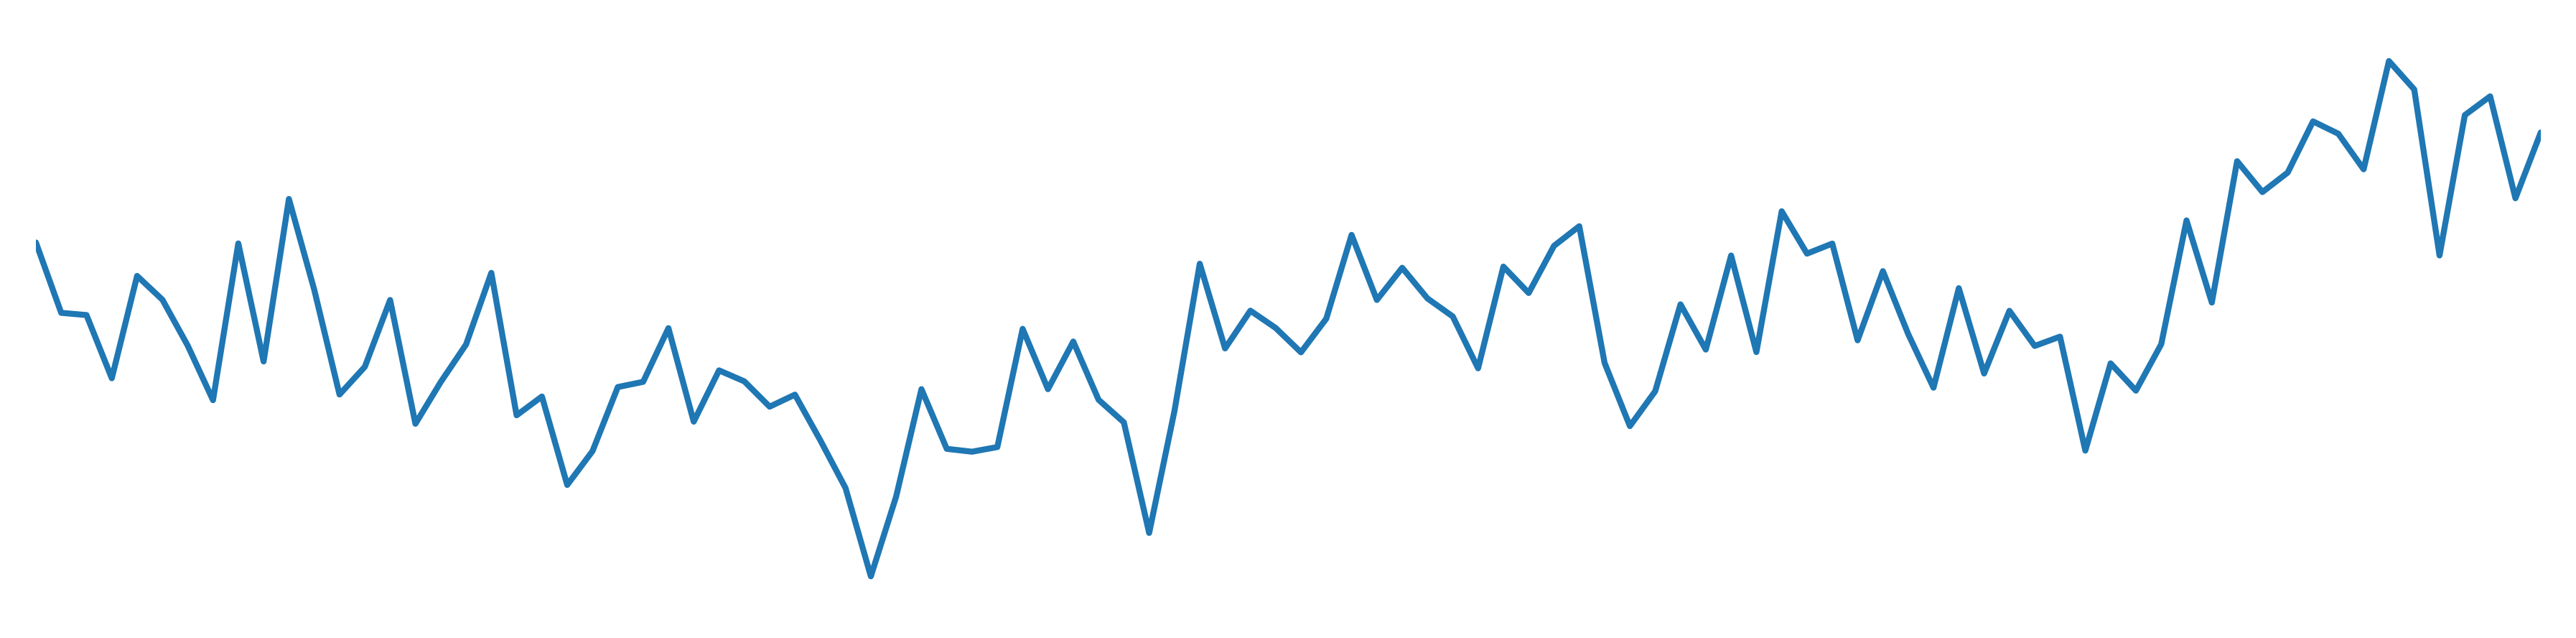

array([ 0.81712139,  0.11000037,  0.08770272, -0.54732287,  0.48089913,
        0.24211186, -0.2189825 , -0.76758105,  0.80750394, -0.37871602,
        1.25441814,  0.34337983, -0.71054494, -0.43246269,  0.23919604,
       -1.00470328, -0.58514041, -0.20836499,  0.51184595, -0.9194969 ,
       -0.73063582, -1.61929214, -1.27910149, -0.63563353, -0.58331013,
       -0.04381928, -0.98346031, -0.46807414, -0.57841098, -0.8328892 ,
       -0.71198112, -1.16935408, -1.65069104, -2.53740979, -1.73559463,
       -0.65676755, -1.25652826, -1.2853185 , -1.23852206, -0.05082216,
       -0.65695357, -0.17819123, -0.76311648, -0.9904241 , -2.10157729,
       -0.87618256,  0.60362405, -0.24764474,  0.13178385, -0.04202083,
       -0.2866579 ,  0.05135745,  0.89308656,  0.23956651,  0.56275386,
        0.25457216,  0.07346407, -0.44720873,  0.574763  ,  0.30944461,
        0.78303999,  0.98035098, -0.39282238, -1.02807689, -0.67783552,
        0.19544421, -0.25912911,  0.68593276, -0.28418493,  1.13

In [4]:
def plot_channel(channel, *, clip=None, color="#1f77b4", figsize=(7, 1.6), linewidth=1.2):
    """Plot a single z-scored channel as a 1D time series line."""
    raw = np.load(DATASET / "timeseries.npy").astype(float)
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T
    M, T = raw.shape
    if not 0 <= channel < M:
        raise IndexError(f"channel {channel} out of range for M={M}")
    series = zscore(raw, axis=1, nan_policy="omit")[channel]
    series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
    if clip is not None:
        series = series[clip[0]:clip[1]]
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.plot(np.arange(series.size), series, color=color, linewidth=linewidth)
    # ax.axhline(0.0, color="black", linewidth=0.5, alpha=0.5)
    ax.set_xlim(0, series.size - 1)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    fig.tight_layout(pad=0.05)
    clip_tag = f"_clip-{clip[0]}-{clip[1]}" if clip else ""
    fig.savefig(output_dir / f"channel-{channel}{clip_tag}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return series

plot_channel(0)
# plot_channel(0, clip=(100, 300))

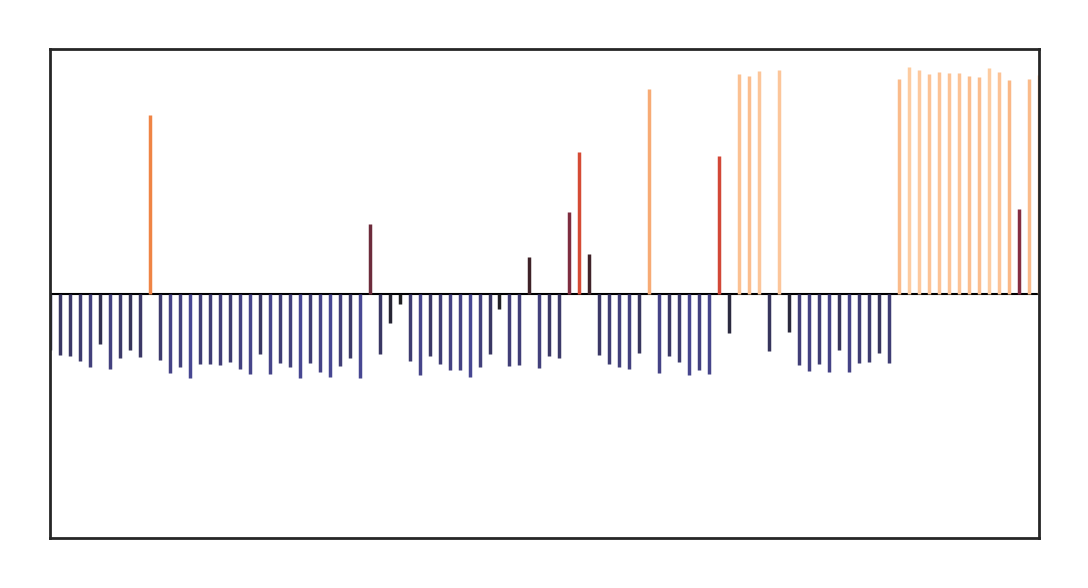

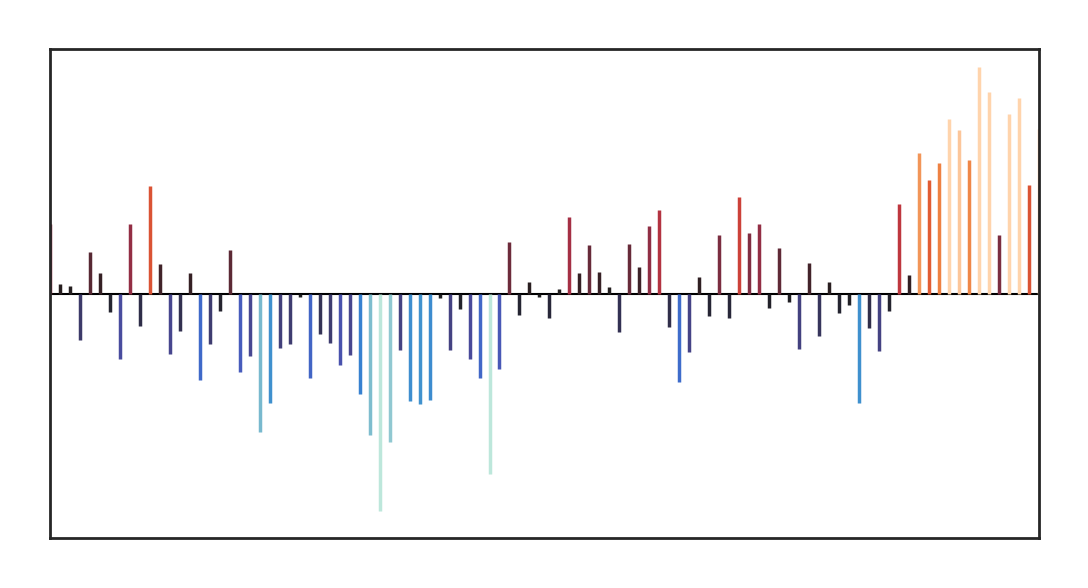

array([ 0.81712139,  0.11000037,  0.08770272, -0.54732287,  0.48089913,
        0.24211186, -0.2189825 , -0.76758105,  0.80750394, -0.37871602,
        1.25441814,  0.34337983, -0.71054494, -0.43246269,  0.23919604,
       -1.00470328, -0.58514041, -0.20836499,  0.51184595, -0.9194969 ,
       -0.73063582, -1.61929214, -1.27910149, -0.63563353, -0.58331013,
       -0.04381928, -0.98346031, -0.46807414, -0.57841098, -0.8328892 ,
       -0.71198112, -1.16935408, -1.65069104, -2.53740979, -1.73559463,
       -0.65676755, -1.25652826, -1.2853185 , -1.23852206, -0.05082216,
       -0.65695357, -0.17819123, -0.76311648, -0.9904241 , -2.10157729,
       -0.87618256,  0.60362405, -0.24764474,  0.13178385, -0.04202083,
       -0.2866579 ,  0.05135745,  0.89308656,  0.23956651,  0.56275386,
        0.25457216,  0.07346407, -0.44720873,  0.574763  ,  0.30944461,
        0.78303999,  0.98035098, -0.39282238, -1.02807689, -0.67783552,
        0.19544421, -0.25912911,  0.68593276, -0.28418493,  1.13

In [5]:
def plot_channel_stem(channel, *, clip=None, cmap="icefire", vmin=-2.0, vmax=2.0,
                      figsize=(2, 1), linewidth=0.5, markersize=0.0):
    """Stem plot of a z-scored channel; each stem + head is colored by its value
    under the MTS-heatmap colormap (icefire, same vmin/vmax). Baseline y=0 centered."""
    raw = np.load(DATASET / "timeseries.npy").astype(float)
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T
    M, T = raw.shape
    if not 0 <= channel < M:
        raise IndexError(f"channel {channel} out of range for M={M}")
    series = zscore(raw, axis=1, nan_policy="omit")[channel]
    series = np.nan_to_num(series, nan=0.0, posinf=0.0, neginf=0.0)
    if clip is not None:
        series = series[clip[0]:clip[1]]
    x = np.arange(series.size)
    cm = sns.color_palette(cmap, as_cmap=True)
    colors = cm(plt.Normalize(vmin, vmax)(series))  # per-sample color = heatmap color

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.axhline(0.0, color="black", linewidth=0.3, zorder=1)
    ax.vlines(x, 0.0, series, colors=colors, linewidth=linewidth, zorder=2)
    ax.scatter(x, series, s=markersize, c=colors, edgecolors="none",
               linewidths=0.5, zorder=3)
    m = max(np.abs(series).max() * 1.08, 1e-9)
    ax.set_xlim(0, series.size - 1)
    ax.set_ylim(-m, m)  # symmetric -> horizontal axis centered
    ax.set_xticks([]); ax.set_yticks([])
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)
    # ax.spines["left"].set_visible(False)
    # ax.spines["bottom"].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
    # ax.spines["bottom"].set_position(("data", 0.0))  # move horizontal axis to y=0
    fig.tight_layout(pad=0.05)
    clip_tag = f"_clip-{clip[0]}-{clip[1]}" if clip else ""
    fig.savefig(output_dir / f"channel-stem-{channel}{clip_tag}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return series

plot_channel_stem(6)
plot_channel_stem(0)
# plot_channel_stem(3, clip=(0,120))
# plot_channel_stem(8, clip=(0,120))

### Scatter of two channels $(i)$ vs $(j)$ from MTS

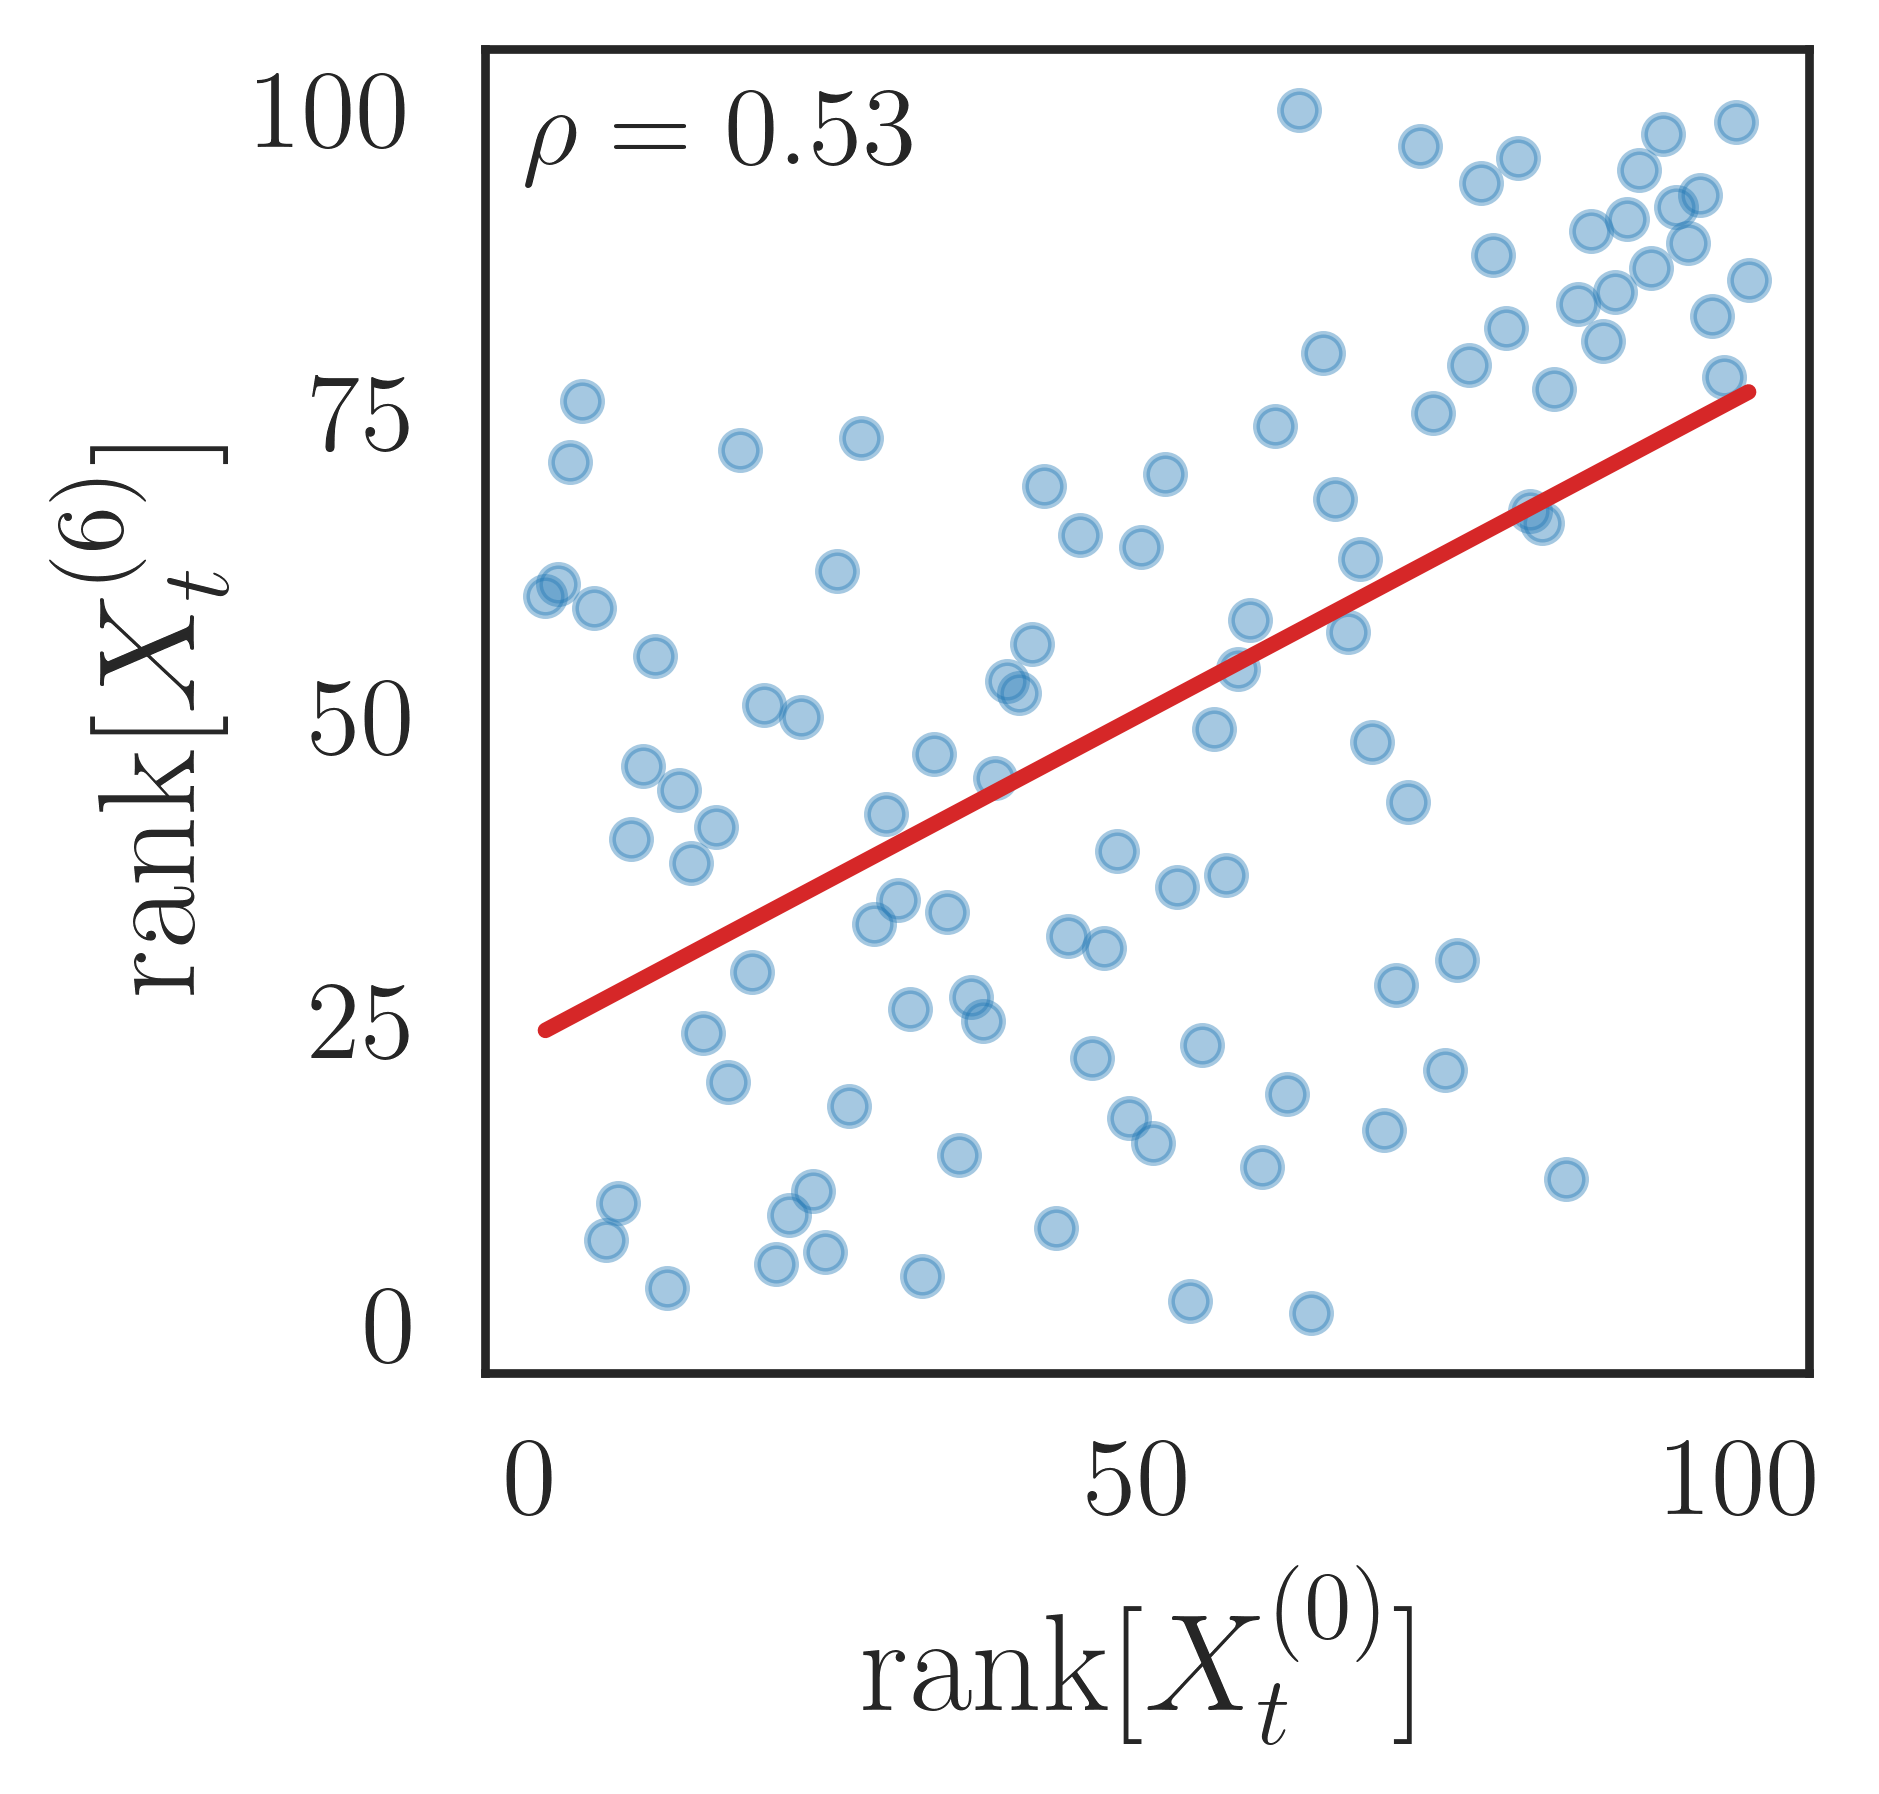

In [8]:
from scipy.stats import rankdata
from sklearn.feature_selection import mutual_info_regression


def plot_channel_scatter(channel_x, channel_y, *, metric="pearson", clip=None,
                         scatter_color="#1f77b4", reg_color="#d62728",
                         scatter_s=30, scatter_alpha=0.4, mi_neighbors=3,
                         figsize=(4, 4), dpi=dpi):
    """Scatter one z-scored channel against another in channel-channel space.

    metric:
      "pearson"  -> linear fit + r (linear association).
      "spearman" -> ranks both axes, linear fit in rank space + rho
                    (Spearman == Pearson on ranks).
      "mi"       -> raw scatter + LOWESS smoother that *tracks* the cloud, and
                    annotates the KSG mutual-information estimate. NOTE: the
                    curve is a nonparametric smoother, not "the MI"; MI is a
                    scalar dependence measure with no regression line.
    """
    raw = np.load(DATASET / "timeseries.npy").astype(float)
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T
    M, T = raw.shape
    for c in (channel_x, channel_y):
        if not 0 <= c < M:
            raise IndexError(f"channel {c} out of range for M={M}")
    Z = zscore(raw, axis=1, nan_policy="omit")
    Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
    x = Z[channel_x]; y = Z[channel_y]
    if clip is not None:
        x = x[clip[0]:clip[1]]; y = y[clip[0]:clip[1]]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    xlab = rf"$X^{{({channel_x})}}$"; ylab = rf"$X^{{({channel_y})}}$"

    if metric == "pearson":
        stat = float(np.corrcoef(x, y)[0, 1])
        ax.scatter(x, y, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=reg_color, ci=None)
        label = rf"$r = {stat:.2f}$"

    elif metric == "spearman":
        rho = float(spearmanr(x, y).statistic)
        x, y = rankdata(x), rankdata(y)          # Spearman == Pearson on ranks
        ax.scatter(x, y, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=reg_color, ci=None)
        label = rf"$\rho = {rho:.2f}$"
        xlab = rf"$\mathrm{{rank}} [X^{{({channel_x})}}_t]$"
        ylab = rf"$\mathrm{{rank}} [X^{{({channel_y})}}_t]$"

    elif metric == "mi":
        mi = float(mutual_info_regression(
            x.reshape(-1, 1), y, n_neighbors=mi_neighbors, random_state=0)[0])
        ax.scatter(x, y, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=reg_color, lowess=True)
        label = rf"$\mathrm{{MI}} = {mi:.2f}$"

    else:
        raise ValueError(f"unknown metric {metric!r}; use 'pearson'|'spearman'|'mi'")

    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.text(0.03, 0.97, label, transform=ax.transAxes, ha="left", va="top")
    ax.set_box_aspect(1)
    fig.tight_layout()
    clip_tag = f"_clip-{clip[0]}-{clip[1]}" if clip else ""
    fig.savefig(output_dir / f"channel_scatter_{channel_x}_vs_{channel_y}_{metric}{clip_tag}_{TAG}.{save_fmt}",
                dpi=dpi, bbox_inches="tight")
    plt.show()


# plot_channel_scatter(0, 6, metric="pearson")
plot_channel_scatter(0, 6, metric="spearman")
# plot_channel_scatter(0, 6, metric="mi")

## MPI heatmaps for `cov_EmpiricalCovariance`, `spearmanr`, `mi_kraskov_NN-4`

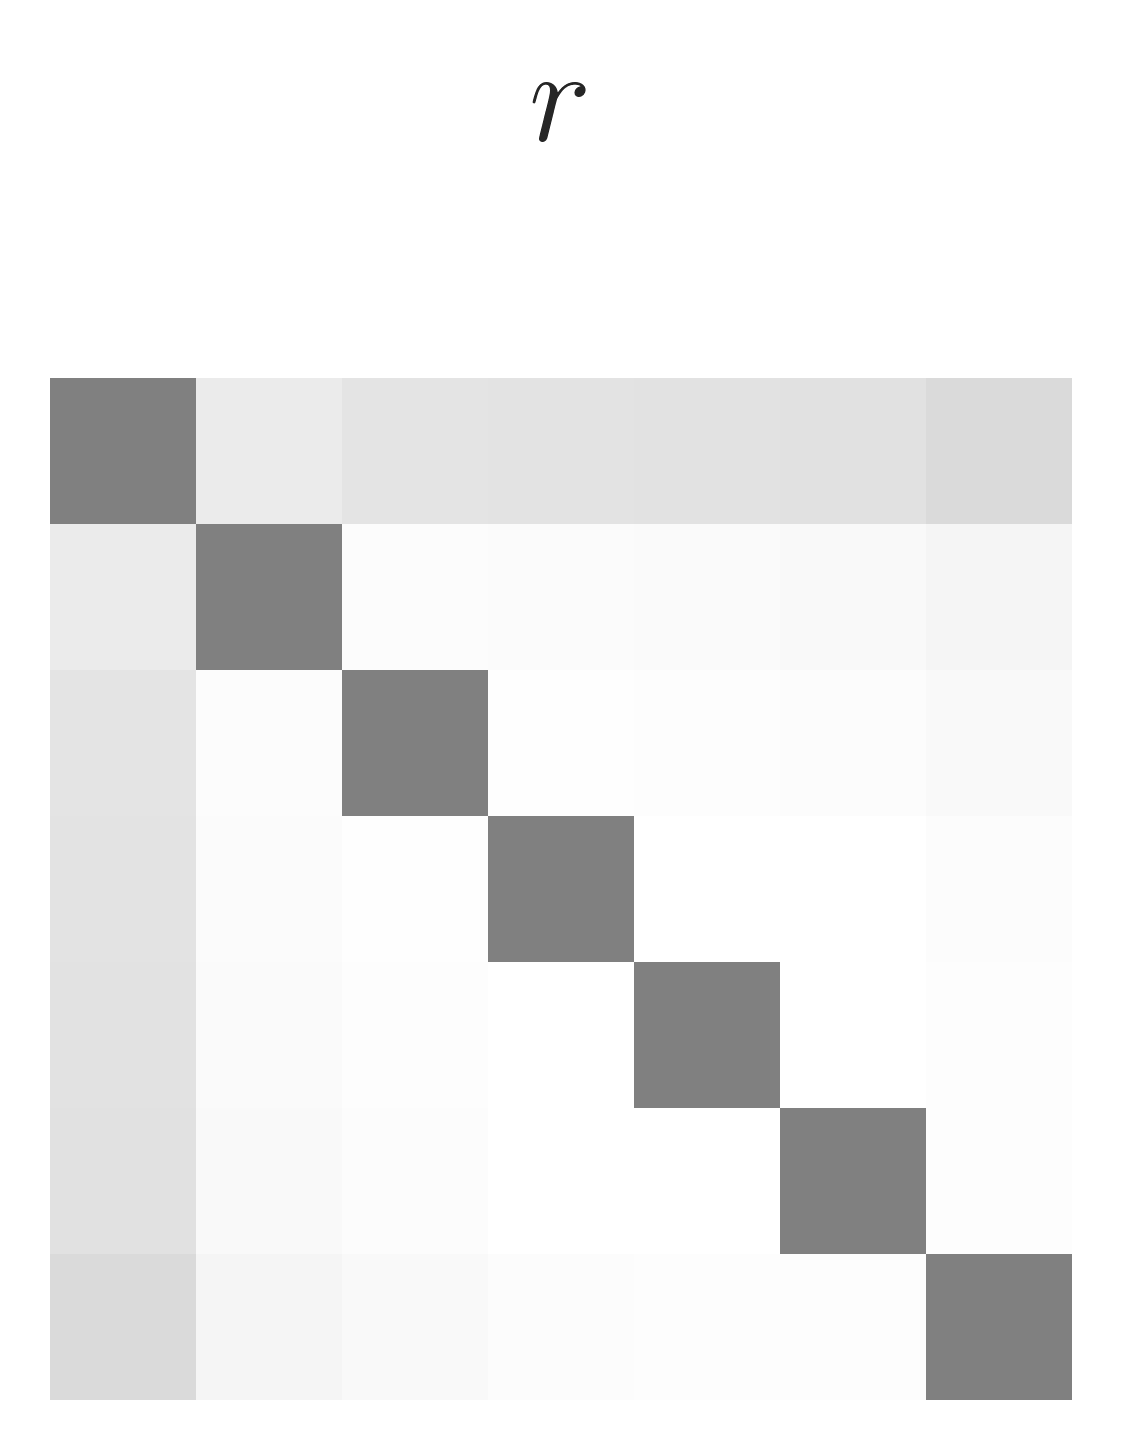

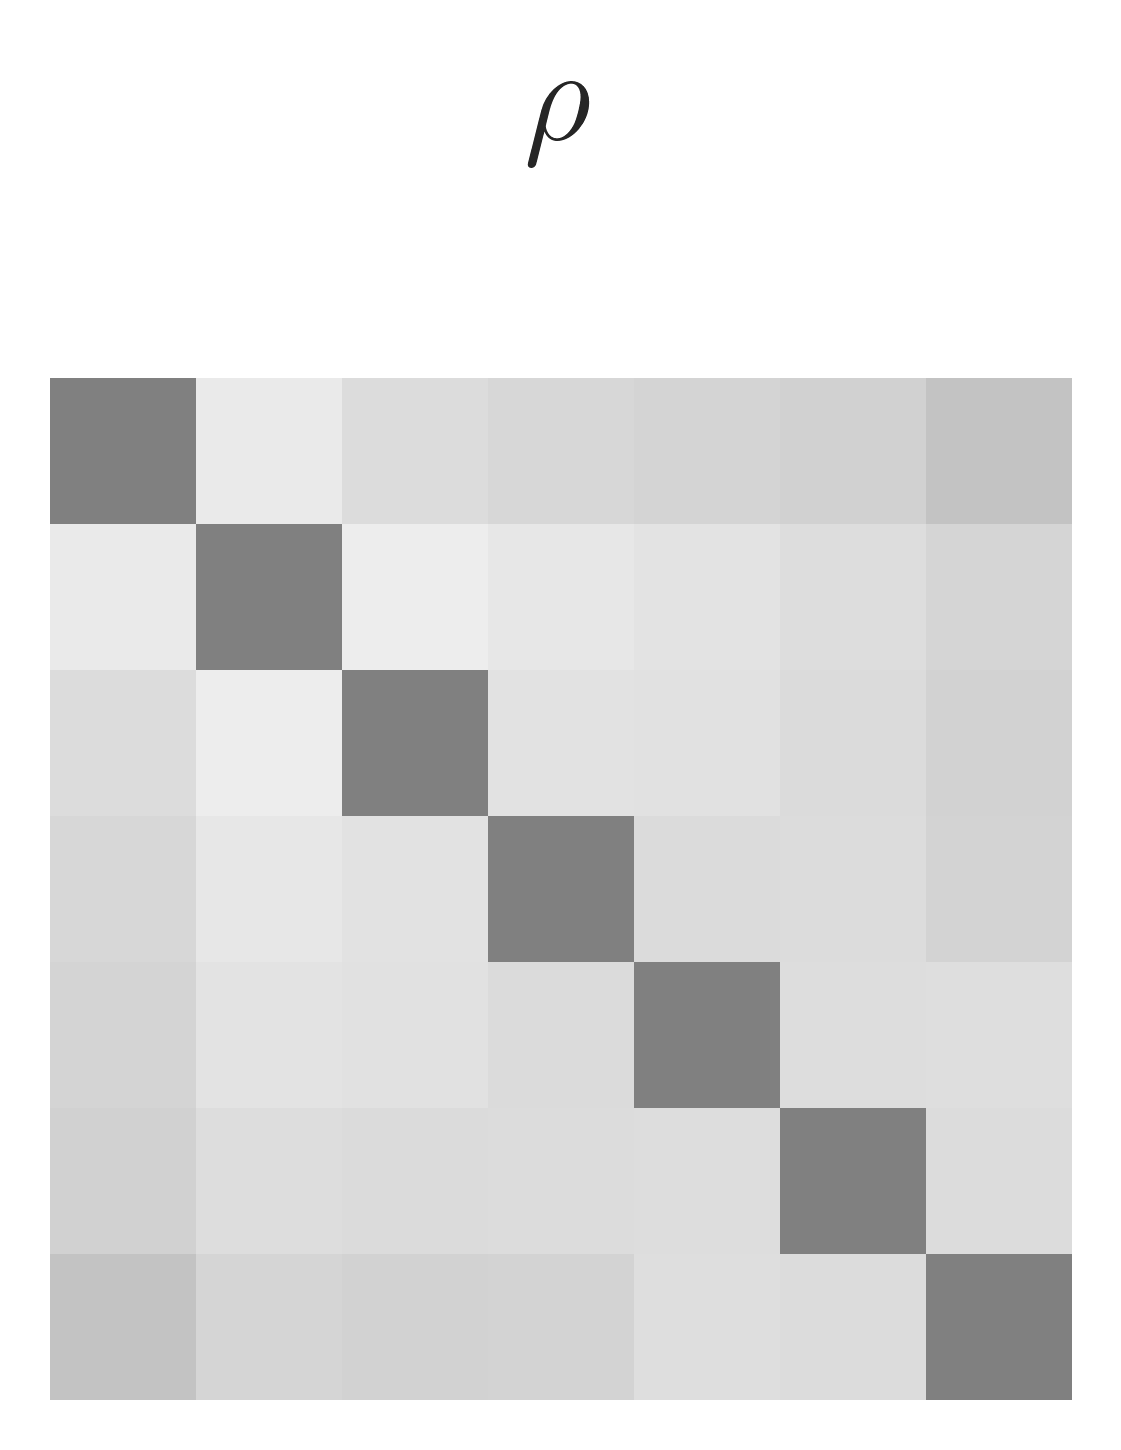

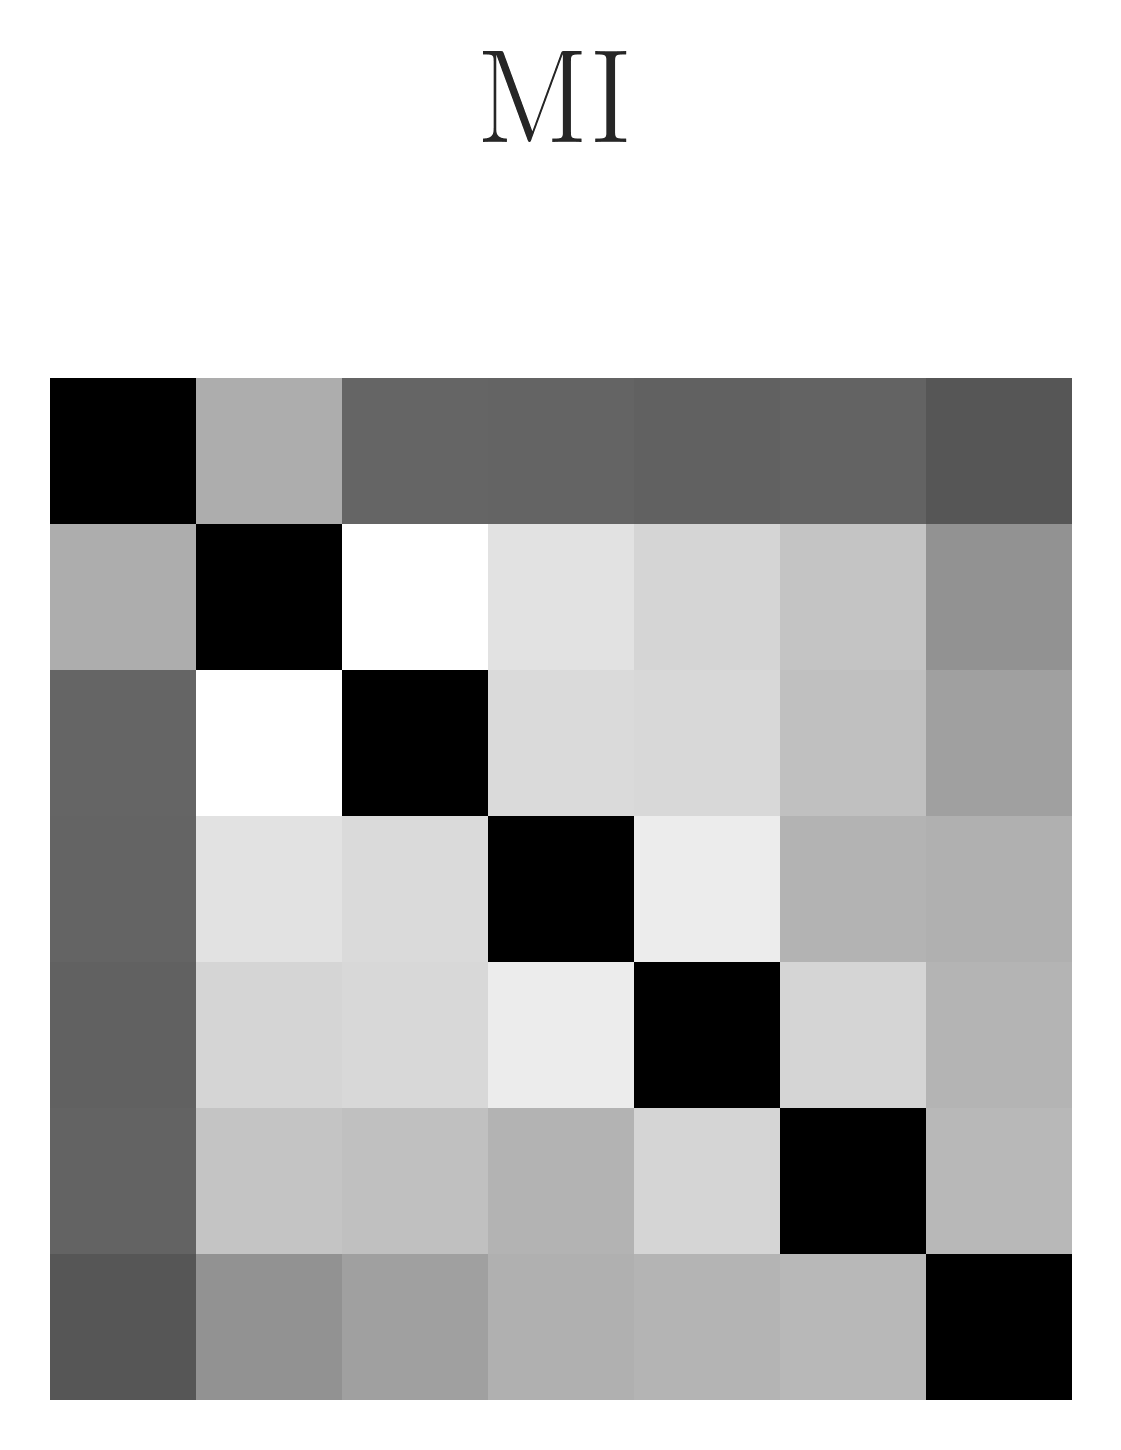

array([[0.        , 0.72438049, 0.42346185, 0.42143018, 0.40598409,
        0.41575494, 0.35992725],
       [0.72438049, 0.        , 1.06970414, 0.94638516, 0.89220837,
        0.82235836, 0.61247624],
       [0.42346185, 1.06970414, 0.        , 0.91416501, 0.90656289,
        0.80599863, 0.67228195],
       [0.42143018, 0.94638516, 0.91416501, 0.        , 0.98815773,
        0.74812704, 0.73900094],
       [0.40598409, 0.89220837, 0.90656289, 0.98815773, 0.        ,
        0.8930321 , 0.75561354],
       [0.41575494, 0.82235836, 0.80599863, 0.74812704, 0.8930321 ,
        0.        , 0.7717801 ],
       [0.35992725, 0.61247624, 0.67228195, 0.73900094, 0.75561354,
        0.7717801 , 0.        ]])

In [10]:
def plot_mpi_heatmap(spi, *, title=None, show_title=False, cmap="gray",
                     vmin=None, vmax=None, center=None, mask_diagonal=False,
                     figsize=(3, 3), dpi=dpi):
    """Heatmap of one SPI's MPI matrix from ARCHIVE.

    spi:           SPI key in spi_mpis.npz (e.g. "cov_EmpiricalCovariance").
    title:         caption text; None -> use the spi name.
    show_title:    whether to draw the title.
    cmap:          any matplotlib/seaborn colormap.
    vmin/vmax/center: color bounds; None -> auto from data.
    mask_diagonal: NaN-out the diagonal (self-coupling) for the plot only.
    Returns the (unmasked) matrix.
    """
    with np.load(ARCHIVE) as npz:
        mat = np.asarray(npz[spi], float)
    plot_mat = mat.copy()
    if mask_diagonal:
        np.fill_diagonal(plot_mat, np.nan)  # NaN cells transparent; skipped by auto vmin/vmax
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    sns.heatmap(plot_mat, cmap=cmap, vmin=vmin, vmax=vmax, center=center,
                square=True, xticklabels=False, yticklabels=False, cbar=False, ax=ax)
    ax.set_xlabel(None); ax.set_ylabel(None)
    if show_title:
        t = title if title is not None else spi
        fig.suptitle(t.replace("_", r"\_") if use_latex else t)
    fig.tight_layout()
    fig.savefig(output_dir / f"mpi_heatmap_{spi}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()
    return mat


# ---- tweakable: per-SPI cmap and color bounds. None -> auto from data. ----
SPIS_MPI = {
    # name:                    (cmap,   vmin,  vmax,  center,  title)
    "cov_EmpiricalCovariance": ("gray", -1.0,  1.0,   0.0,   r"$r$"),
    "spearmanr":               ("gray", -1.0,  1.0,   0.0,   r"$\rho$"),
    "mi_kraskov_NN-4":         ("gray", None,  None,  None,  r"$\mathrm{MI}$"),
}

mask_diagonal = False   # diagonal is self-coupling (max); exclude to avoid cmap bias
show_title = True     # toggle SPI name above each heatmap
cmap="gray"

plot_mpi_heatmap("cov_EmpiricalCovariance", title=r"$r$", show_title=True,
                cmap=cmap,vmin=-1, vmax=1, center=0, mask_diagonal=mask_diagonal)

plot_mpi_heatmap("spearmanr", title=r"$\rho$", show_title=True, 
                cmap=cmap, vmin=-1, vmax=1, center=0, mask_diagonal=mask_diagonal)

plot_mpi_heatmap("mi_kraskov_NN-4", title=r"$\mathrm{MI}$", show_title=True, 
                cmap=cmap, vmin=0, vmax=None, center=None, mask_diagonal=mask_diagonal)

## Unravel off-diagonals into a 1D vector heatmap ("barcode")

Always symmetrises each matrix (mean of upper and lower) and takes the lower-triangular off-diagonals.

In [14]:
# ---- tweakable ----
barcode_width_per_entry = 0.18  # figure-width scaling per off-diag entry

def plot_barcode(vec, name, cmap, vmin, vmax, center, title):
    width = max(4.0, vec.size * barcode_width_per_entry)
    fig, ax = plt.subplots(figsize=(width, 1), dpi=dpi)
    sns.heatmap(
        vec[np.newaxis, :],
        cmap=cmap, vmin=vmin, vmax=vmax, center=center,
        cbar=False, xticklabels=False, yticklabels=False, ax=ax,
    )
    ax.set_xticks([]); ax.set_yticks([])
    ax.tick_params(left=False, bottom=False)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_title(title, pad=4)
    fig.tight_layout(pad=0.05)
    fig.savefig(output_dir / f"barcode_{name}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()

for name, (cmap, vmin, vmax, center, title) in SPIS_MPI.items():
    mat = spi_mats[name]
    sym = 0.5 * (mat + mat.T)
    lower = np.tril(np.ones(sym.shape, bool), k=-1)
    plot_barcode(sym[lower], name, cmap, vmin, vmax, center, title)

NameError: name 'spi_mats' is not defined

## Two SPIs against each other (SPI-SPI space)

Symmetrises each matrix and uses the upper triangle. Set `spi_x` / `spi_y` to any pair from `spi_mpis.npz`.

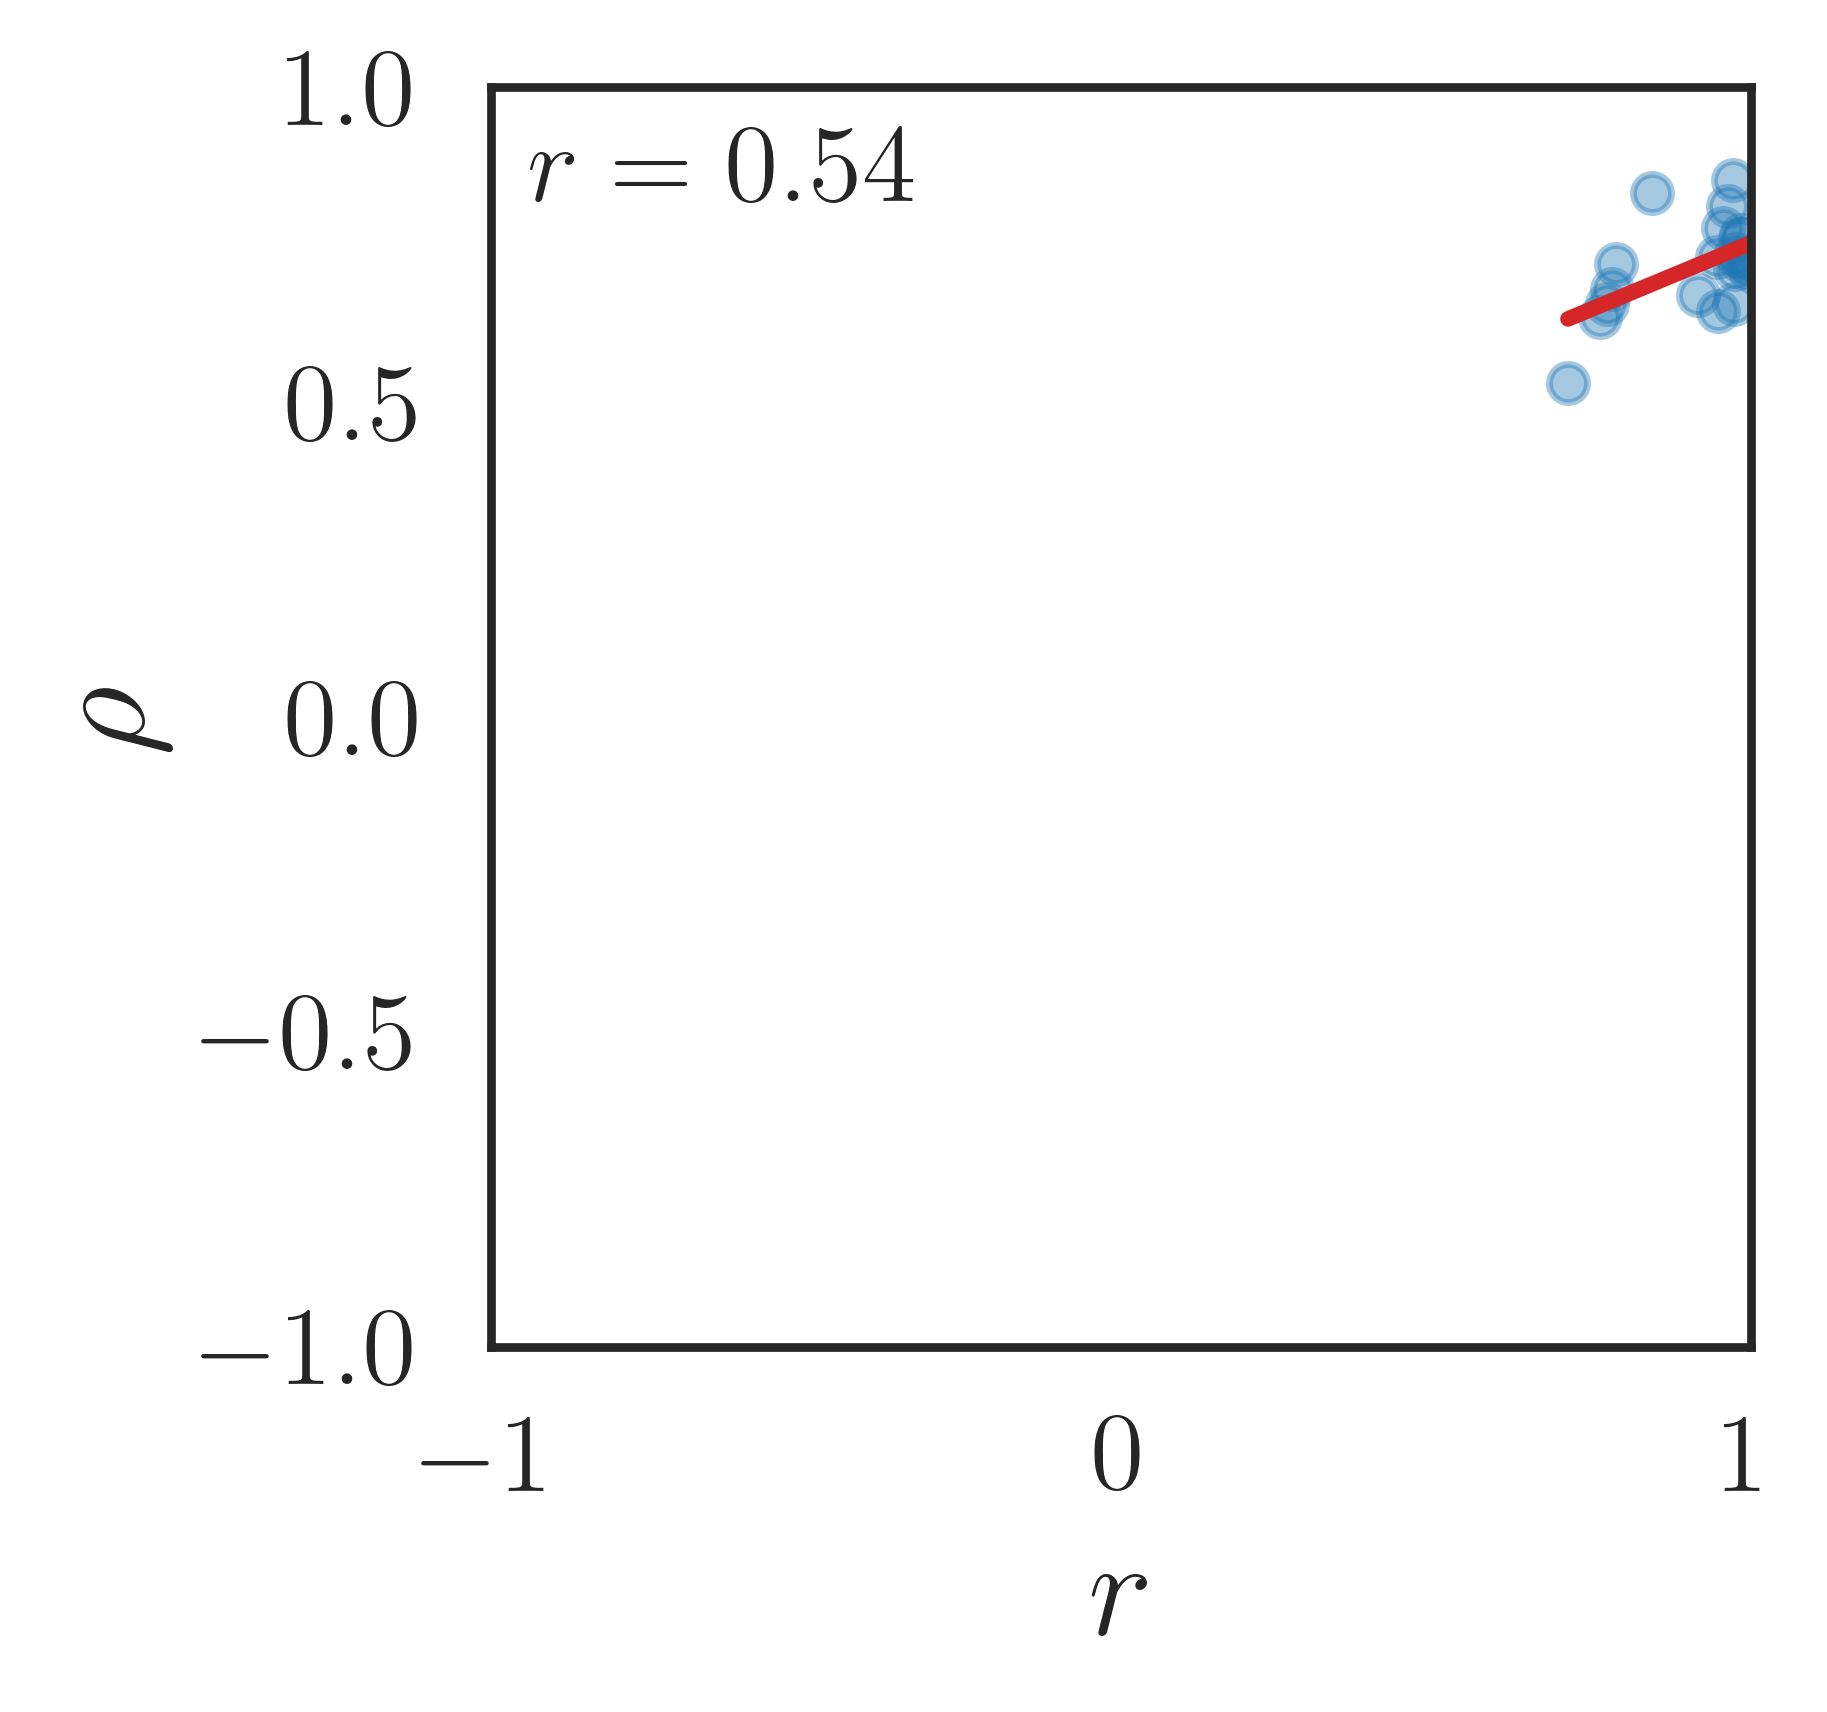

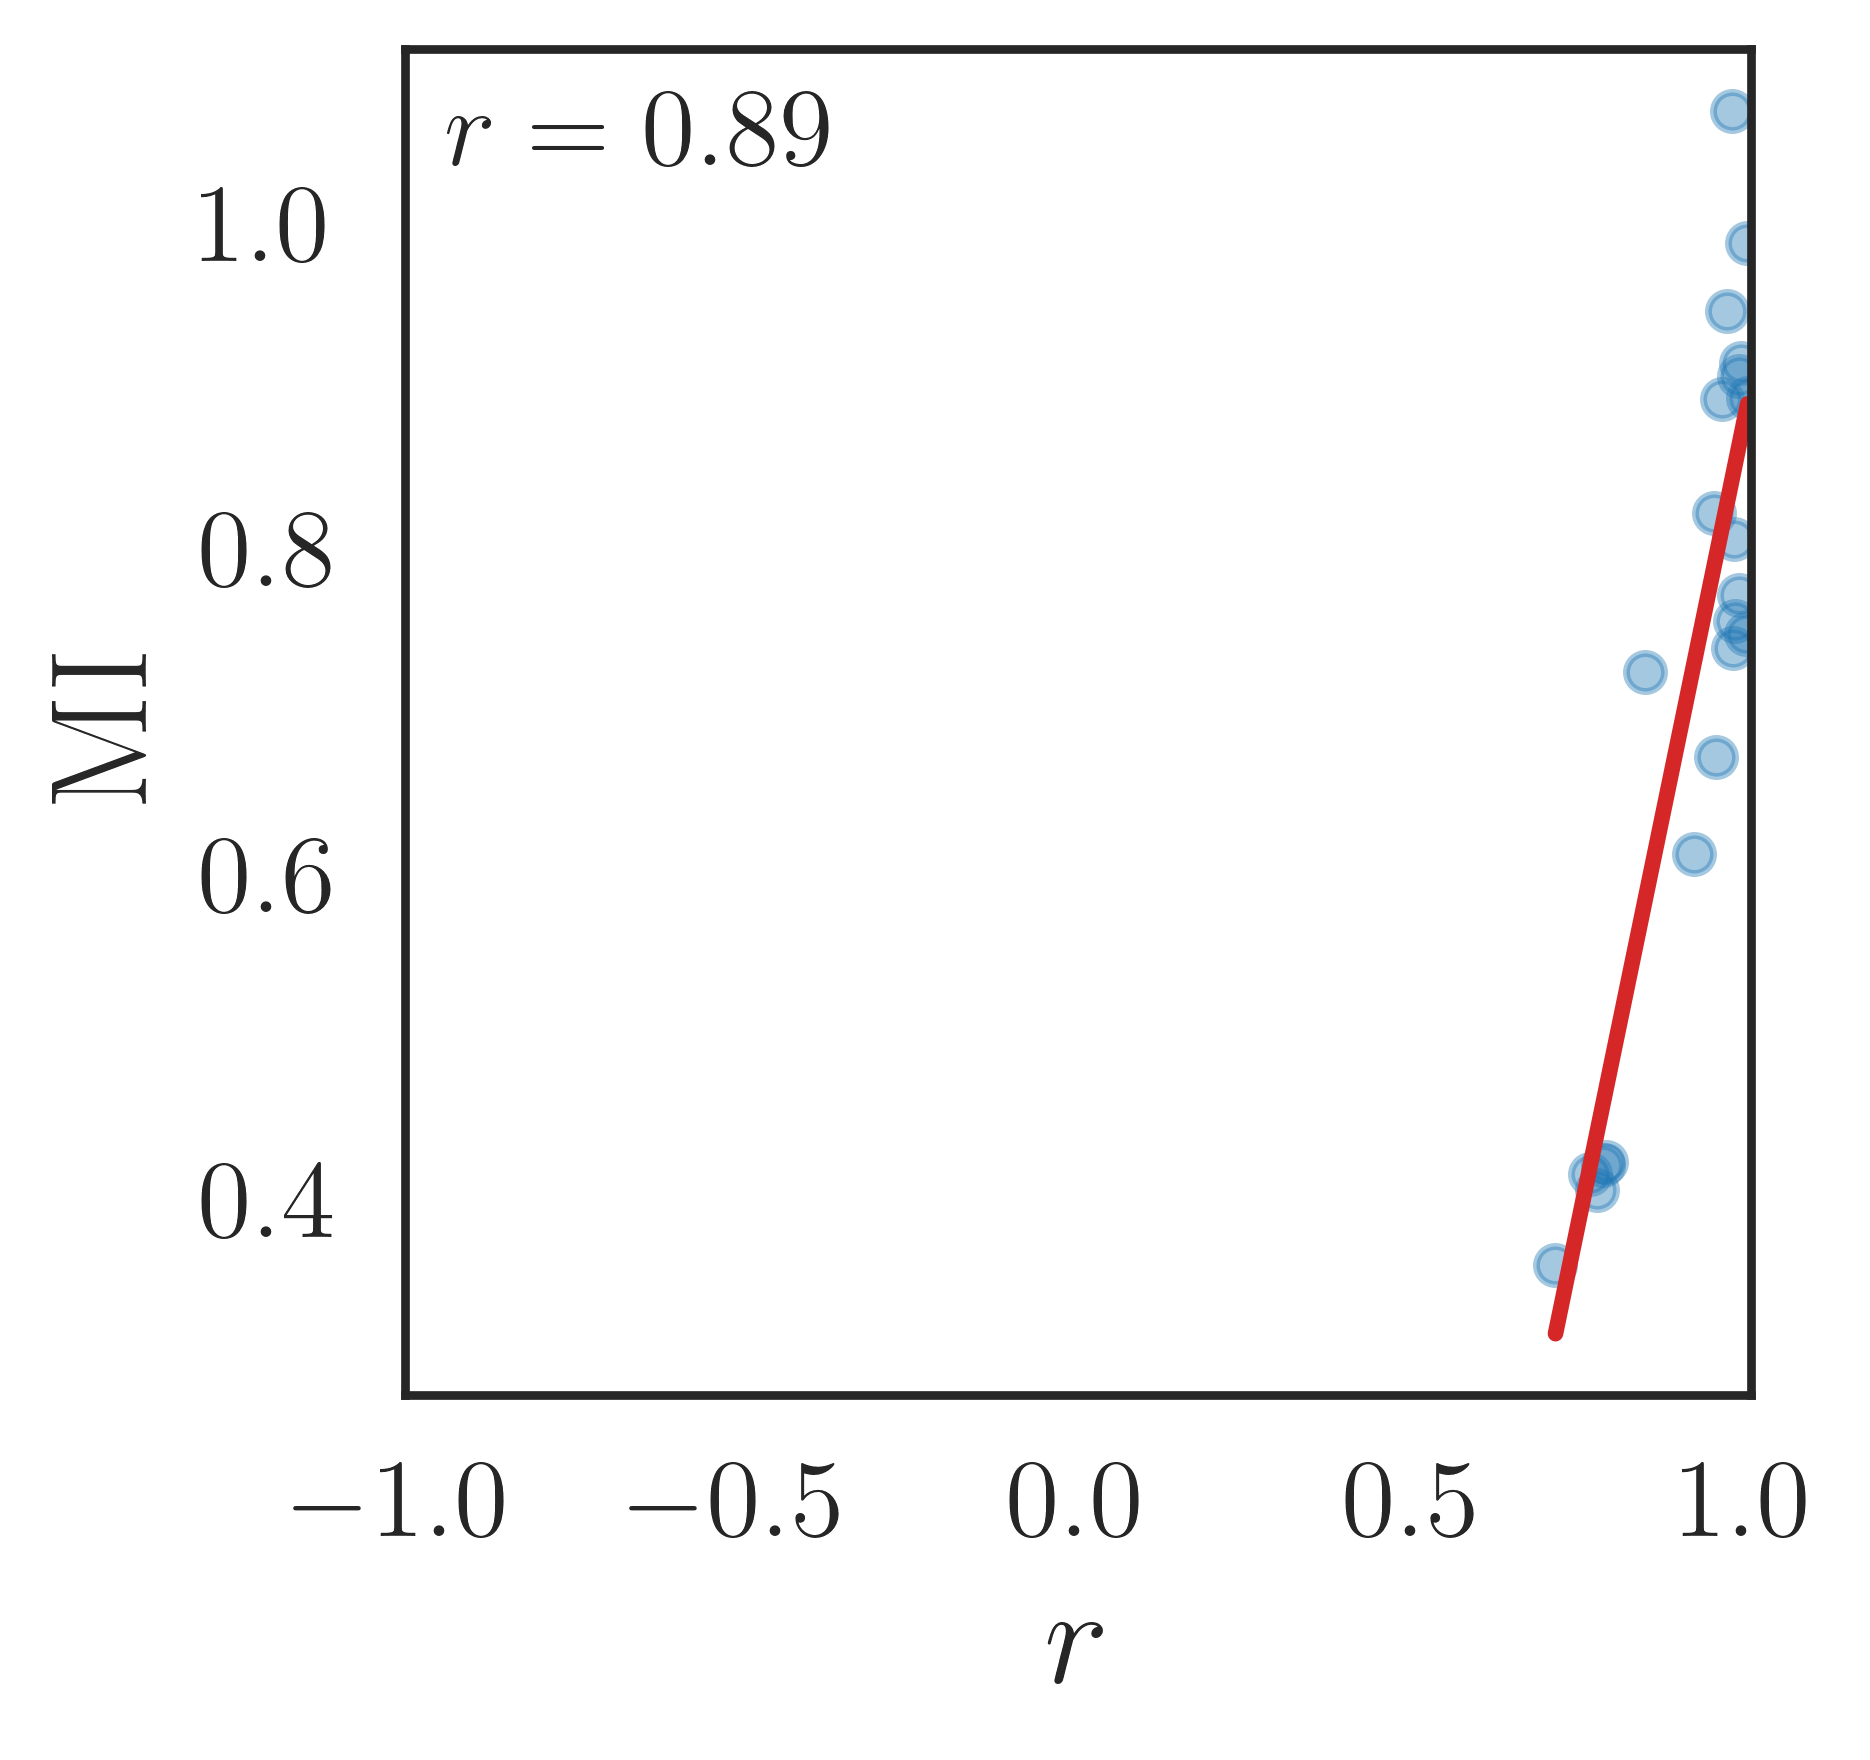

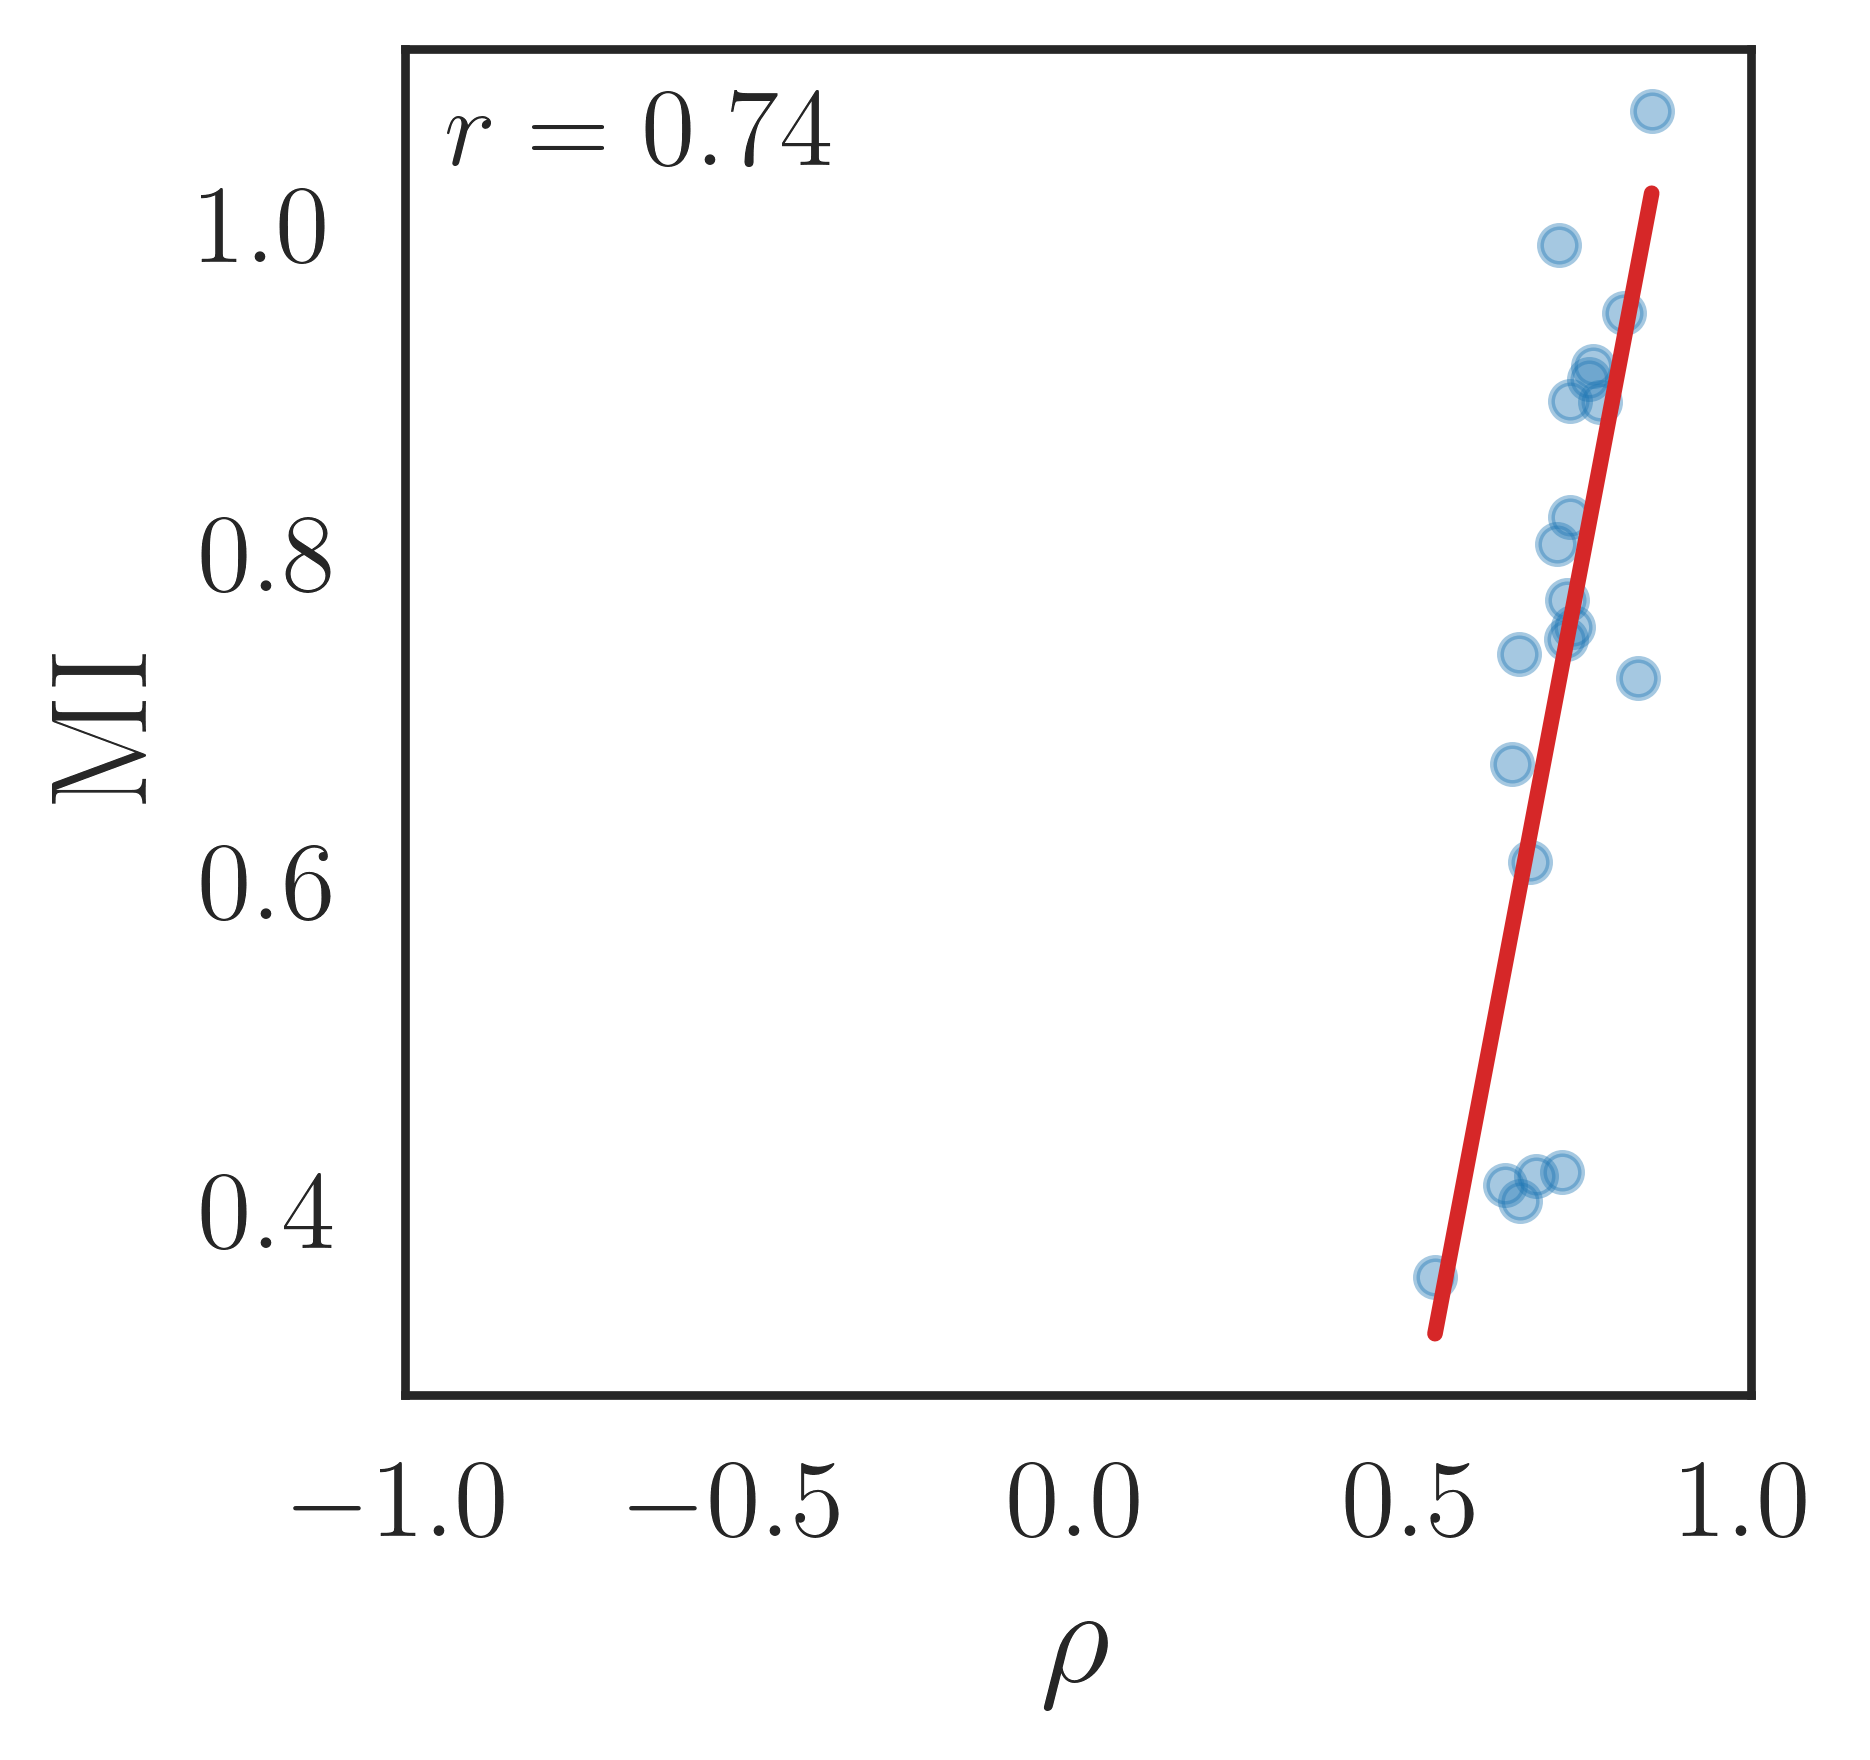

In [15]:
# ---- tweakable ----
spi_x = "mi_kraskov_NN-4"; label_x = r"$\mathrm{MI}$"
spi_y = "cov_EmpiricalCovariance"; label_y = r"$r$"
scatter_color = "#1f77b4"
reg_color = "#d62728"
scatter_s = 30
scatter_alpha = 0.4

def plot_spi_spi_scatter(spi_x, spi_y, label_x=None, label_y=None, x_lim=None, y_lim=None,
                         dpi=dpi, figsize=(4,4)):
    with np.load(ARCHIVE) as npz:
        A = np.asarray(npz[spi_x], float)
        B = np.asarray(npz[spi_y], float)
    A = 0.5 * (A + A.T)
    B = 0.5 * (B + B.T)
    mask = np.triu(np.ones(A.shape, bool), k=1)
    x_vals = A[mask]; y_vals = B[mask]
    finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_vals = x_vals[finite]; y_vals = y_vals[finite]

    r = float(np.corrcoef(x_vals, y_vals)[0, 1])

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.scatter(x_vals, y_vals, s=scatter_s, alpha=scatter_alpha, color=scatter_color)
    sns.regplot(x=x_vals, y=y_vals, ax=ax, scatter=False, color=reg_color, ci=None)
    xl = label_x or spi_x.replace("_", r"\_") if use_latex else spi_x
    yl = label_y or spi_y.replace("_", r"\_") if use_latex else spi_y
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    if x_lim is not None:
        ax.set_xlim(*x_lim)
    if y_lim is not None:
        ax.set_ylim(*y_lim)
    ax.text(
        0.03, 0.97,
        f"$r = {r:.2f}$",
        transform=ax.transAxes, ha="left", va="top",
    )
    ax.set_box_aspect(1) 
    fig.tight_layout()
    fig.savefig(output_dir / f"spi_space_{spi_x}_vs_{spi_y}_{TAG}.{save_fmt}", dpi=dpi, bbox_inches="tight")
    plt.show()

plot_spi_spi_scatter("cov_EmpiricalCovariance", "spearmanr", label_x=r"$r$", label_y=r"$\rho$", x_lim=(-1.0, 1.0), y_lim=(-1.0, 1.0))
plot_spi_spi_scatter("cov_EmpiricalCovariance", "mi_kraskov_NN-4", label_x=r"$r$", label_y=r"$\mathrm{MI}$", x_lim=(-1.0, 1.0), y_lim=None)
plot_spi_spi_scatter("spearmanr", "mi_kraskov_NN-4", label_x=r"$\rho$", label_y=r"$\mathrm{MI}$", x_lim=(-1.0, 1.0), y_lim=None)